01_data_preparation

02_feature_extraction_and_ml_traning

03_acoustic_DL

04_linguistic_DL

05_image_DL

# Imports

In [1]:
!pip install google-cloud-storage pydub librosa matplotlib

In [2]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Configurations

In [ ]:
from google.colab import auth
auth.authenticate_user()

# To find the credentials automatically
from google.cloud import storage
client = storage.Client(project=GCP_PROJECT_ID) # GCP Project ID


In [ ]:
# Initialize GCP Storage
client = storage.Client()
bucket_name = VOICE_DATA_BUCKET_NAME # GCP Storage bucket name
bucket = client.get_bucket(bucket_name)
print(f"Bucket {bucket.name} successfully loaded.")

Bucket voicedata-bucket successfully loaded.


In [ ]:

print(os.getcwd()) 

/content


In [6]:
# Configuration
PREFIX_AUDIO = 'WLS/audio'
PREFIX_TRANSCRIPT = 'WLS/transcripts'
CATEGORIES = ['CN', 'AD']

# Ensure local directories exist for processing
os.makedirs("local_data/audio", exist_ok=True)
os.makedirs("local_data/transcripts", exist_ok=True)
os.makedirs("local_data/processed_audio", exist_ok=True)

# Create Ground Truth CSV (extract labels for audio files)

In [7]:
# Generate Ground Truth CSV
# uses the GCS bucket to figure out which patient belongs to which category.

ground_truth_data = []
print("Scanning GCS bucket to generate ground truth labels for WLS...")

for category in CATEGORIES:
    category_prefix = f"{PREFIX_AUDIO}/{category}/"
    blobs = bucket.list_blobs(prefix=category_prefix)

    for blob in blobs:
        if blob.name.endswith('.mp3'): # In .mp3
            file_name = os.path.basename(blob.name)
            participant_id = file_name.replace('.mp3', '') # In .mp3
            ground_truth_data.append({
                "participant_id": participant_id,
                "label": category,
                "label_numeric": 1 if category == 'AD' else 0 # CN = 0, AD = 1
            })

gt_df = pd.DataFrame(ground_truth_data)
gt_df.to_csv("local_data/ground_truth.csv", index=False)
print(f"Success! Created ground truth for {len(gt_df)} participants.\n")
display(gt_df.head())

Scanning GCS bucket to generate ground truth labels for WLS...
Success! Created ground truth for 40 participants.



,participant_id,label,label_numeric
0,00137,CN,0
1,00399,CN,0
2,01362,CN,0
3,01379,CN,0
4,01748,CN,0


# Extract Participant Speech

Raw Audio => Full Transcripts

=> Participant-only Audio

=> Participant-only Transcripts

Processing .cha (CHAT format) files requires a specialized parsing approach, as these files contain rich metadata and custom timestamp enclosures (like 19757_21477).

By directly parsing these .cha files using regular expressions, we can extract exactly what the participant said including repetitions, false starts, and filler words and use the exact millisecond boundaries to slice the raw audio. This guarantees that intra-turn pauses and specific acoustic features are preserved for downstream models.

In [8]:
# Method for CHA Parsing & Audio Extraction Engine
def process_cha_file(cha_path):
    """
    Parses CHAT format to extract both Participant and Investigator segments (text and millisecond timestamps).
    For interviwer, extract lines like: *INV:	please take a look at this picture and describe everything that you see here . 150_15220
    For participants, extract lines like: *PAR:	water running over the sink . 19757_21477
    """
    # Regex to capture the text, start_ms, and end_ms
    par_pattern = re.compile(r'^\*PAR:\s*(.*?)\s*\x15(\d+)_(\d+)\x15')
    inv_pattern = re.compile(r'^\*INV:\s*(.*?)\s*\x15(\d+)_(\d+)\x15')

    par_segments = []
    inv_segments = []

    with open(cha_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            # Capture Participant Data
            if line.startswith('*PAR:'):
                match = par_pattern.search(line)
                if match:
                    par_segments.append({
                        'text': match.group(1).strip(),
                        'start': int(match.group(2)),
                        'end': int(match.group(3))
                    })
            # Capture Investigator Data
            elif line.startswith('*INV:'):
                match = inv_pattern.search(line)
                if match:
                    inv_segments.append({
                        'start': int(match.group(2)),
                        'end': int(match.group(3))
                    })

    return par_segments, inv_segments

The "Bounding Box & Subtract" Algorithm
- keeping everything that isn't the interviewer can accidentally include irrelevant pre-test silence or post-test wrap-up. Instead, we use a "Bounding Box" approach:

  - Find the bounds: Identify the start time of the participant's very first word and the end time of their very last word. This block represents the entire cognitive test.

  - Subtract the Investigator: Take that entire block of time (which naturally includes all the participant's pauses) and computationally "punch out" any overlapping *INV timestamps (e.g., if the investigator interjects with a "mhm" or a prompt).

In [9]:
# Method to extract participant audio and transcripts

from pydub import AudioSegment

def extract_wls_participant_data(audio_path, transcript_path, output_audio_path):
    """
    Extracts the full duration of the participant's test, preserving pauses,
    while removing any investigator interruptions.
    """
    try:
        # 1. Decode Audio
        try:
            audio = AudioSegment.from_mp3(audio_path)
        except Exception as e:
            return None, True, f"Failed to decode raw audio: {e}"

        # 2. Parse Transcript for BOTH speakers
        try:
            par_segments, inv_segments = process_cha_file(transcript_path)
        except Exception as e:
             return None, True, f"Failed to read .cha file: {e}"

        if not par_segments:
            return None, True, "No *PAR: segments with valid timestamps found."

        # 3. Create the "Bounding Box" of the participant's task
        first_par_start = par_segments[0]['start']
        last_par_end = par_segments[-1]['end']

        # 4. Define intervals to keep, subtracting INV interruptions
        keep_intervals = [{'start': first_par_start, 'end': last_par_end}]

        for inv in inv_segments:
            new_keep = []
            for interval in keep_intervals:
                # If INV overlaps with this interval, split the interval
                if inv['end'] <= interval['start'] or inv['start'] >= interval['end']:
                    new_keep.append(interval) # No overlap, keep the interval as is
                else:
                    # Overlap exists. Split around the investigator's speech
                    if interval['start'] < inv['start']:
                        new_keep.append({'start': interval['start'], 'end': inv['start']})
                    if interval['end'] > inv['end']:
                        new_keep.append({'start': inv['end'], 'end': interval['end']})
            keep_intervals = new_keep

        # 5. Extract and Concatenate the safe intervals (Speech + Pauses)
        participant_audio = AudioSegment.empty()
        for interval in keep_intervals:
            participant_audio += audio[interval['start']:interval['end']]

        # Export the robust audio
        participant_audio.export(output_audio_path, format="wav")

        # Integrity Check
        if os.path.getsize(output_audio_path) == 0:
            return None, True, "Exported audio file is 0 bytes."

        # Reconstruct the transcript text (just the participant words)
        full_transcript = " ".join([seg['text'] for seg in par_segments])

        return full_transcript, False, None

    except Exception as e:
        return None, True, f"Unexpected pipeline error: {e}"

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


In [10]:

# Execution Loop & Verification Report

# This cell loops through the categories, downloads the files, processes them through the engine above,
# handles unrecoverable file cleanup, and prints the requested integrity counts.
# Execution Loop & Verification Report

processed_data = []
corrupted_files = []

for category in CATEGORIES:
    print(f"\nProcessing category: {category}")
    category_audio_prefix = f"{PREFIX_AUDIO}/{category}/"
    blobs = bucket.list_blobs(prefix=category_audio_prefix)

    for blob in blobs:
        if not blob.name.endswith('.mp3'): # In .mp3
            continue

        file_name = os.path.basename(blob.name)
        base_id = file_name.replace('.mp3', '') # In .mp3

        local_mp3 = f"local_data/audio/{file_name}" # The downloaded raw file is .mp3
        local_cha = f"local_data/transcripts/{base_id}.cha"
        output_wav = f"local_data/processed_audio/{base_id}_par.wav" # Processed output remains .wav

        gcs_cha_blob_name = f"{PREFIX_TRANSCRIPT}/{category}/{base_id}.cha"
        cha_blob = bucket.blob(gcs_cha_blob_name)

        # Download Audio
        if not os.path.exists(local_mp3):
            blob.download_to_filename(local_mp3)

        # Download Transcript
        if not os.path.exists(local_cha):
            if cha_blob.exists():
                cha_blob.download_to_filename(local_cha)
            else:
                corrupted_files.append((base_id, "Missing .cha transcript file on GCS"))
                continue

        # Process and Verify
        transcript_text, is_corrupt, error_msg = extract_wls_participant_data(local_mp3, local_cha, output_wav)

        if is_corrupt:
            corrupted_files.append((base_id, error_msg))
            # Automated cleanup of corrupted outputs
            if os.path.exists(output_wav):
                os.remove(output_wav)
        else:
            processed_data.append({
                "participant_id": base_id,
                "audio_path": output_wav,
                "transcript": transcript_text
            })

# Merge and Finalize Dataframe
if not processed_data:
    print("\n[!] CRITICAL: No files were successfully processed. 'processed_data' is empty.")
    # Create an empty dataframe with the correct columns to prevent the merge crash
    df_processed = pd.DataFrame(columns=["participant_id", "audio_path", "transcript"])
else:
    df_processed = pd.DataFrame(processed_data)

final_df = pd.merge(df_processed, gt_df, on="participant_id", how="inner")

# Verification Report
print("\n" + "="*50)
print("VERIFICATION REPORT")
print("="*50)

if corrupted_files:
    print(f"\n[!] Identified {len(corrupted_files)} corrupted or unrecoverable files:")
    # Print the first 10 errors
    for file_id, error in corrupted_files[:10]:
        print(f"  - {file_id}: {error}")
    if len(corrupted_files) > 10:
        print(f"  ... and {len(corrupted_files) - 10} more.")
else:
    print("\n[✓] Zero corrupted files detected. All data loaded successfully.")

print(f"\nTotal Participants Processed Successfully: {len(final_df)}")
print(f"Total Participants Dropped/Corrupted: {len(corrupted_files)}")
print("="*50)


Processing category: CN

Processing category: AD

VERIFICATION REPORT

[✓] Zero corrupted files detected. All data loaded successfully.

Total Participants Processed Successfully: 40
Total Participants Dropped/Corrupted: 0


In [11]:
# Display a sample transcript to verify parsing worked
display(final_df.head())

,participant_id,audio_path,transcript,label,label_numeric
0,00137,local_data/processed_audio/00137_par.wav,"xxx boom . a lady doing dishes , the water run...",CN,0
1,00399,local_data/processed_audio/00399_par.wav,"girl , boy . mother . water running out_of the...",CN,0
2,01362,local_data/processed_audio/01362_par.wav,ah a kid stealing cookies . and the stool is g...,CN,0
3,01379,local_data/processed_audio/01379_par.wav,everything I see . you mean from a safety aspe...,CN,0
4,01748,local_data/processed_audio/01748_par.wav,well ‡ the kids are trying to get into the coo...,CN,0


### Verification of Interviewer Removal

In [12]:
from IPython.display import Audio

# Play the original
print("Original Audio (Contains Interviewer):")
display(Audio("local_data/audio/00199.mp3"))


Original Audio (Contains Interviewer):


In [13]:
# Play the processed version to hear the difference
print("Processed Audio (Participant Only):")
display(Audio("local_data/processed_audio/00199_par.wav"))

Output hidden; open in https://colab.research.google.com to view.

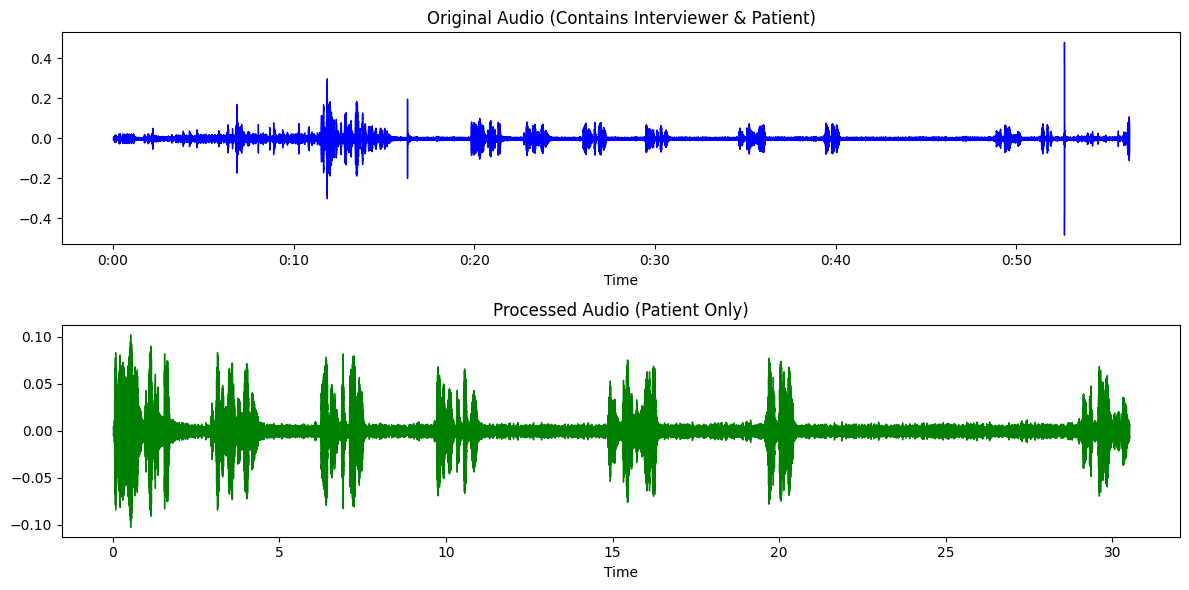

In [14]:
# Visual Test (Waveform Visualization Before & After)

import librosa
import librosa.display


def plot_waveforms(original_path, processed_path):
    y_orig, sr_orig = librosa.load(original_path, sr=None)
    y_proc, sr_proc = librosa.load(processed_path, sr=None)

    fig, ax = plt.subplots(nrows=2, sharex=False, figsize=(12, 6))
    librosa.display.waveshow(y_orig, sr=sr_orig, ax=ax[0], color="blue")
    ax[0].set(title='Original Audio (Contains Interviewer & Patient)')

    librosa.display.waveshow(y_proc, sr=sr_proc, ax=ax[1], color="green")
    ax[1].set(title='Processed Audio (Patient Only)')
    plt.tight_layout()
    plt.show()

plot_waveforms("local_data/audio/00199.mp3", "local_data/processed_audio/00199_par.wav")


To see the true, relative amplitude between the original and processed audio,
we need to lock the Y-axes of both plots together.

Right now, Matplotlib is automatically zooming in on the bottom plot because it's quieter.

By adding sharey=True to the plt.subplots() function, Matplotlib will force both the top and bottom waveforms to use the exact same vertical scale.

This will show exactly how much quieter the isolated participant audio is compared to the original recording that contained the loud interviewer.

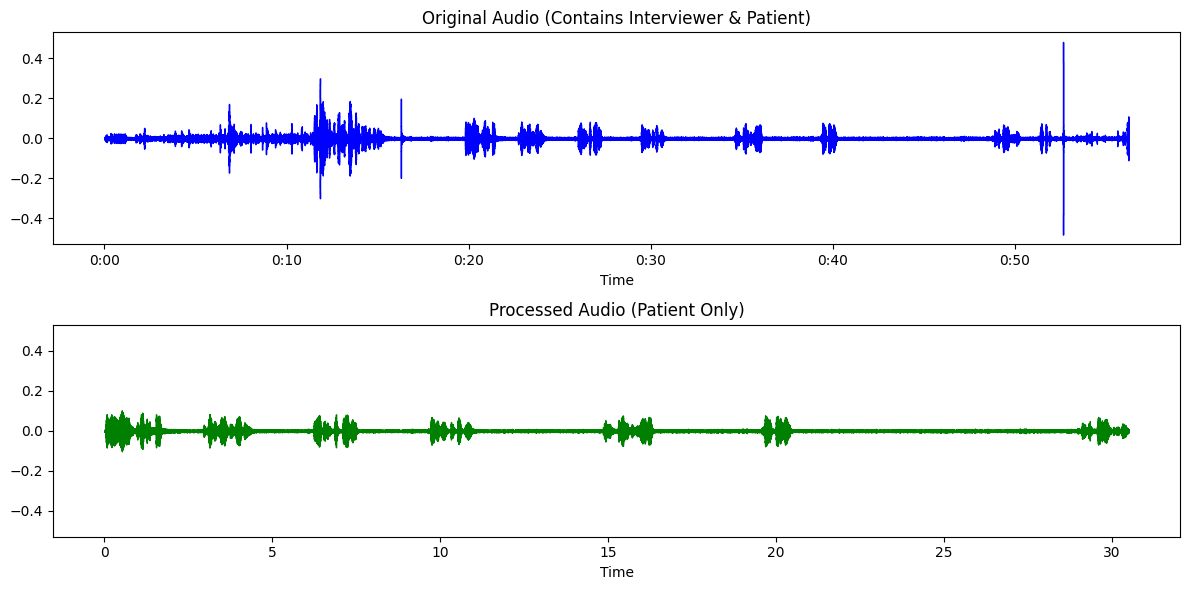

In [15]:
# Visual Test (Waveform Visualization Before & After)

import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_waveforms(original_path, processed_path):
    y_orig, sr_orig = librosa.load(original_path, sr=None)
    y_proc, sr_proc = librosa.load(processed_path, sr=None)

    # ADDED sharey=True to lock the amplitude scales together
    fig, ax = plt.subplots(nrows=2, sharex=False, sharey=True, figsize=(12, 6))

    librosa.display.waveshow(y_orig, sr=sr_orig, ax=ax[0], color="blue")
    ax[0].set(title='Original Audio (Contains Interviewer & Patient)')

    librosa.display.waveshow(y_proc, sr=sr_proc, ax=ax[1], color="green")
    ax[1].set(title='Processed Audio (Patient Only)')

    plt.tight_layout()
    plt.show()

plot_waveforms("local_data/audio/00199.mp3", "local_data/processed_audio/00199_par.wav")

### Transcript - Before vs After Interviewer Removal

In [23]:
import textwrap
import re
import os

# Define the target
participant_target = '00199'
cha_path = f"local_data/transcripts/{participant_target}.cha"

print(f"      ORIGINAL TRANSCRIPT: {participant_target} (INV & PAR)       \n")

if os.path.exists(cha_path):
    # Regex to capture BOTH speakers and strip out the 0x15 timestamps
    pattern = re.compile(r'^\*(INV|PAR):\s*(.*?)\s*\x15(\d+)_(\d+)\x15')

    with open(cha_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            match = pattern.search(line)

            if match:
                speaker = match.group(1) # Captures 'INV' or 'PAR'
                text = match.group(2).strip()

                if text:
                    # Capitalize the first letter for a polished look
                    clean_text = text[0].upper() + text[1:]

                    # Wrap text and align subsequent lines under the speaker prefix
                    wrapped_utterance = textwrap.fill(
                        f"{speaker}: {clean_text}.",
                        width=70,
                        subsequent_indent="     "
                    )
                    print(wrapped_utterance)
                    print() # Blank space between utterances


else:
    print(f"Could not find the original .cha file at {cha_path}")

      ORIGINAL TRANSCRIPT: 00199 (INV & PAR)       

INV: Please take a look at this picture and describe everything that
     you see here ..

PAR: Water running over the sink ..

PAR: A woman washing dishes ..

PAR: Stool being tipped over ..

PAR: Children after cookies ..

PAR: A woman standing in the water ..

PAR: Boy falling ..

PAR: Dishes still left to be done ..

INV: Alright ‡ thank_you ..



In [16]:
# Filter the dataframe for the specific participant ID
sample_row = final_df[final_df['participant_id'] == '00199']

# Check if the participant exists in the dataframe, then print
if not sample_row.empty:
    # .values[0] extracts just the text string instead of the whole pandas series
    transcript_text = sample_row['transcript'].values[0]
    print(f"Transcript for 00199:\n\n{transcript_text}")
else:
    print("Could not find 00199 in the dataframe.")

Transcript for 00199:

water running over the sink . a woman washing dishes . stool being tipped over . children after cookies . a woman standing in the water . boy falling . dishes still left to be done .


In [20]:
import textwrap

# Filter the dataframe for the specific participant ID
sample_row = final_df[final_df['participant_id'] == '00199']

if not sample_row.empty:
    transcript_text = sample_row['transcript'].values[0]

    # Create a clean header
    print("               TRANSCRIPT: 00199                  \n")

    # Split the text by the CHAT format punctuation
    utterances = [u.strip() for u in transcript_text.split(' . ') if u.strip()]

    for utterance in utterances:
        # Capitalize the first letter of each utterance for a polished look
        clean_utterance = utterance.capitalize()

        # Add a bullet point and wrap the text to 70 characters
        # subsequent_indent ensures wrapped lines align cleanly under the text, not the bullet
        wrapped_utterance = textwrap.fill(
            f" {clean_utterance}.",
            width=70,
            subsequent_indent="  "
        )
        print(wrapped_utterance)
        print() # Adds a blank space between utterances for readability


else:
    print("Could not find 00199 in the dataframe.")

               TRANSCRIPT: 00199                  

 Water running over the sink.

 A woman washing dishes.

 Stool being tipped over.

 Children after cookies.

 A woman standing in the water.

 Boy falling.

 Dishes still left to be done ..



# Upload the created files into the GCP Bucket

In [18]:
def upload_to_gcs(local_file_path, gcs_destination_blob_name):
    """Uploads a single file to the GCS bucket."""
    blob = bucket.blob(gcs_destination_blob_name)
    blob.upload_from_filename(local_file_path)

print("Saving final validated dataframe to local CSV...")
final_csv_path = "local_data/final_transcripts_wls.csv"
final_df.to_csv(final_csv_path, index=False)

print("Uploading WLS Ground Truth and Final Transcripts to GCS...")
upload_to_gcs("local_data/ground_truth.csv", "WLS/processed/ground_truth.csv")
upload_to_gcs(final_csv_path, "WLS/processed/final_transcripts.csv")

processed_files = glob.glob("local_data/processed_audio/*_par.wav")
print(f"Starting upload of {len(processed_files)} validated audio files...")

for local_audio in processed_files:
    file_name = os.path.basename(local_audio)
    gcs_path = f"WLS/processed/audio/{file_name}"
    upload_to_gcs(local_audio, gcs_path)

print("Success! All cleaned WLS participant data is backed up to GCS.")

Saving final validated dataframe to local CSV...
Uploading WLS Ground Truth and Final Transcripts to GCS...
Starting upload of 40 validated audio files...
Success! All cleaned WLS participant data is backed up to GCS.
